In [1]:
# Cell 1: Cài thư viện
!pip install -q transformers==4.44.* --force-reinstall
!pip install -q numpy==1.26.4 --force-reinstall
!pip install -q rouge_score underthesea bert-score nltk datasets timm einops tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 80.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━

In [ ]:
# # Cell 2: Restart kernel sau khi cài
# import os; os.kill(os.getpid(), 9)

In [1]:
# Cell 3: Config đường dẫn — SỬA CÁC PATH NÀY
from pathlib import Path

VINTERN_MODEL_PATH   = Path("/kaggle/input/datasets/bixunhong/vintern-merge/vintern_finetuned")  # ← model Vintern finetuned merged
PADDLE_JSON_PATH     = "/kaggle/input/datasets/bixunhong/paddle-300/paddle_extracted_300).jsonl"  # ← file JSON paddle extract
TEST_DATASET_SRC     = "/kaggle/input/datasets/maituananh511/test-dataset-chart-vqa/vi_chart_dataset"
VIETNAMESE_DATA_PATH = Path("/kaggle/input/datasets/maituananh511/data-vietnamese/Data Vietnamese")
OUTPUT_CSV           = "/kaggle/working/eval_results.csv"
OUTPUT_ZIP           = "/kaggle/working/eval_results.zip"

print("VINTERN_MODEL_PATH exists:", VINTERN_MODEL_PATH.exists())
print("PADDLE_JSON_PATH   exists:", Path(PADDLE_JSON_PATH).exists())

VINTERN_MODEL_PATH exists: True
PADDLE_JSON_PATH   exists: True


In [2]:
# Cell 4: Load Vintern model
import torch
from transformers import AutoModel, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = AutoModel.from_pretrained(
    str(VINTERN_MODEL_PATH),
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    local_files_only=True,
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained(
    str(VINTERN_MODEL_PATH),
    trust_remote_code=True,
    local_files_only=True,
    use_fast=False,
)
print(" Vintern loaded")

Device: cuda


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention is not installed.
 Vintern loaded


In [3]:
# Cell 5: Load Paddle extracted JSON
import json, re

with open(PADDLE_JSON_PATH, 'r', encoding='utf-8') as f:
    paddle_raw = json.load(f)

# Chuẩn hóa: bỏ _q0/_q1/_q2, lấy base_id
# Và clean text: bỏ "User: Chart Recognition:\nAssistant: "
def clean_paddle(text: str) -> str:
    if not text:
        return ""
    # Bỏ prefix "User: ... Assistant: "
    if "Assistant:" in text:
        text = text.split("Assistant:", 1)[-1].strip()
    return text.strip()

paddle_extracted = {}
for key, val in paddle_raw.items():
    base_id = re.sub(r'_q\d+$', '', key)
    if base_id not in paddle_extracted:
        paddle_extracted[base_id] = clean_paddle(val)

print(f"Paddle extracted: {len(paddle_extracted)} unique images")
print("\nSample:")
for k, v in list(paddle_extracted.items())[:2]:
    print(f"[{k}]: {v[:100]}")

Paddle extracted: 67 unique images

Sample:
[a6565a928ba79c6d0fdf]: Quy 2 | Quy 3 | Quy 4 | Quy 1
10.6 | 34.7 |   |  
6.3 |   |   |
[e4b8ac8293d80aa59e2c]: Các loại bình truyền받i phổ biến | Số ca
Sởi | 78.3
Thủy đâu | 8.8
Sởt xuất huyết | 34.3
Cúm A | 68.2


In [4]:
# Cell 6: Load dataset — COPY CHÍNH XÁC từ notebook gốc
import shutil, os
from datasets import load_from_disk, concatenate_datasets, Dataset
from PIL import Image
import pyarrow as pa

VIETNAMESE_IMAGES_PATH = VIETNAMESE_DATA_PATH / "images"
VIETNAMESE_JSONL_PATH  = VIETNAMESE_DATA_PATH / "viet_chart_vqa.jsonl"

SRC_DATASET = TEST_DATASET_SRC
DST_DATASET = "/kaggle/working/vi_chart_dataset"
if not os.path.exists(DST_DATASET):
    shutil.copytree(SRC_DATASET, DST_DATASET)
vi_chart_dataset = load_from_disk(DST_DATASET)

vietnamese_records = []
with open(VIETNAMESE_JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            vietnamese_records.append(json.loads(line))
print(f"Vietnamese records: {len(vietnamese_records)}")

Vietnamese records: 4957


In [5]:
# Cell 7: Build tập test — COPY CHÍNH XÁC từ notebook gốc
def normalize_turn(turn):
    if isinstance(turn, str):
        return {'role': 'assistant', 'content': turn}
    if isinstance(turn, dict):
        role = turn.get('role') or turn.get('from', '')
        if role in ('human', 'user'):      role = 'user'
        elif role in ('gpt', 'assistant'): role = 'assistant'
        for rk in ('assistant', 'user', 'human', 'gpt'):
            if rk in turn and 'content' not in turn and 'role' not in turn:
                role = 'assistant' if rk in ('assistant', 'gpt') else 'user'
                return {'role': role, 'content': str(turn[rk])}
        content = str(turn.get('content') or turn.get('value', ''))
        return {'role': role, 'content': content}
    return {'role': 'assistant', 'content': str(turn)}

def align_conversations_schema(dataset, reference_dataset):
    ref_conv_type   = reference_dataset.data.schema.field('conversations').type
    ref_struct_type = ref_conv_type.value_type
    field_order = [ref_struct_type.field(i).name for i in range(ref_struct_type.num_fields)]
    pa_table    = dataset.data.table
    conv_arr    = pa_table.column('conversations').combine_chunks()
    struct_arr  = conv_arr.values
    arrays = [struct_arr.field(f) for f in field_order]
    fields = [pa.field(f, pa.string()) for f in field_order]
    new_struct = pa.StructArray.from_arrays(arrays, fields=fields)
    new_conv   = pa.ListArray.from_arrays(conv_arr.offsets, new_struct)
    idx = pa_table.schema.get_field_index('conversations')
    new_table = pa_table.set_column(idx, 'conversations', new_conv)
    return Dataset(new_table)

vn_rows = []
for record in vietnamese_records:
    img_path = VIETNAMESE_IMAGES_PATH / record['image']
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        continue
    convs = [normalize_turn(t) for t in record['conversations']]
    pairs = [(convs[i], convs[i+1]) for i in range(0, len(convs) - 1, 2)]
    for idx, (q, a) in enumerate(pairs):
        record_id = record['id'] if len(pairs) == 1 else f"{record['id']}_q{idx}"
        vn_rows.append({'id': record_id, 'image': image, 'conversations': [q, a]})

TEST_SIZE = 200
vn_test_rows = vn_rows[-TEST_SIZE:]
vi_vietnamese_test = Dataset.from_list(vn_test_rows)
vi_vietnamese_test = align_conversations_schema(vi_vietnamese_test, vi_chart_dataset['test'])
print(f"Test set: {len(vi_vietnamese_test)} samples")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test set: 200 samples


In [6]:
# Cell 8: Hàm load image cho Vintern
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode
import numpy as np

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_transform(input_size):
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1)
        for i in range(1, n + 1) for j in range(1, n + 1)
        if min_num <= i * j <= max_num
    )
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])
    target_aspect_ratio = find_closest_aspect_ratio(aspect_ratio, target_ratios, orig_width, orig_height, image_size)
    target_width  = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width  // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width  // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        processed_images.append(resized_img.crop(box))
    if use_thumbnail and len(processed_images) != 1:
        processed_images.append(image.resize((image_size, image_size)))
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB') if isinstance(image_file, str) else image_file
    image = image.resize((input_size, input_size))
    transform = build_transform(input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = torch.stack([transform(img) for img in images])
    return pixel_values

print("✅ Image utils defined")

✅ Image utils defined


In [7]:
# Cell 9: Cài metric packages
!pip install -q rouge_score underthesea bert-score nltk
import nltk
import os
os.makedirs('/usr/share/nltk_data', exist_ok=True)
nltk.data.path.append('/usr/share/nltk_data')
for pkg in ['punkt', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, download_dir='/usr/share/nltk_data', quiet=True)
print(" Metrics ready")

 Metrics ready


In [10]:
# Cell 10: Hàm tính metrics
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from rouge_score import rouge_scorer
from tqdm import tqdm
from underthesea import word_tokenize

def compute_bertscore(responses, references):
    try:
        import bert_score as bs_lib
        _, _, F1 = bs_lib.score(responses, references, lang='vi', verbose=False,
                                rescale_with_baseline=False)
        return F1.tolist()
    except Exception as e:
        print(f'BERTScore failed: {e}')
        return [0.0] * len(responses)

def vintern_answer(image, question, extracted_data=""):
    if extracted_data:
        prompt = f'<image>\nDữ liệu biểu đồ:\n{extracted_data}\n\n{question}'
    else:
        prompt = f'<image>\n{question}'
    
    pixel_values = load_image(image, max_num=12).to(torch.bfloat16).cuda()
    gen_cfg = dict(max_new_tokens=512, do_sample=False, num_beams=3, repetition_penalty=2.0)
    response = model.chat(tokenizer, pixel_values, prompt, gen_cfg)
    return response

print("✅ Functions defined")

✅ Functions defined


In [11]:
# Cell 11: Chạy eval 2 mode
scorer   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method1

results_A = []  # Vintern only
results_B = []  # Paddle + Vintern

responses_A, responses_B, references = [], [], []

for i in tqdm(range(len(vi_vietnamese_test)), desc="Evaluating"):
    item         = vi_vietnamese_test[i]
    img_id       = str(item['id'])
    base_id      = re.sub(r'_q\d+$', '', img_id)
    image        = item['image']
    question     = str(item['conversations'][0]['content'])
    ground_truth = str(item['conversations'][1]['content'])

    if not isinstance(image, Image.Image):
        image = Image.fromarray(np.array(image)).convert('RGB')

    # Lấy extracted_data từ Paddle
    extracted_data = paddle_extracted.get(base_id, "")

    try:
        # Mode A: Vintern only
        resp_A = vintern_answer(image, question, extracted_data="")
        # Mode B: Paddle + Vintern  
        resp_B = vintern_answer(image, question, extracted_data=extracted_data)
    except Exception as e:
        print(f"Error [{img_id}]: {e}")
        resp_A = resp_B = ""

    responses_A.append(resp_A)
    responses_B.append(resp_B)
    references.append(ground_truth)

    # Tính metrics per sample
    ref_tok  = word_tokenize(ground_truth, format='text').split()
    
    for resp, results_list in [(resp_A, results_A), (resp_B, results_B)]:
        resp_tok = word_tokenize(resp, format='text').split() if resp else []
        try:
            bleu = sentence_bleu([ref_tok], resp_tok, weights=(0.25,)*4, smoothing_function=smoothie)
        except:
            bleu = 0.0
        try:
            meteor = nltk_meteor([ref_tok], resp_tok)
        except:
            meteor = 0.0
        rouge = scorer.score(ground_truth, resp)
        
        results_list.append({
            'id': img_id,
            'question': question,
            'ground_truth': ground_truth,
            'response': resp,
            'bleu': bleu,
            'meteor': meteor,
            'rouge1': rouge['rouge1'].fmeasure,
            'rouge2': rouge['rouge2'].fmeasure,
            'rougeL': rouge['rougeL'].fmeasure,
            'bertscore': 0.0,
            'has_paddle': bool(extracted_data),
        })

print("✅ Inference done!")
print(f"Mode A (Vintern only)   : {len(results_A)} samples")
print(f"Mode B (Paddle+Vintern) : {len(results_B)} samples")

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Evaluating:   0%|          | 1/200 [00:09<30:44,  9.27s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Evaluating:   1%|          | 2/200 [00:17<29:08,  8.83s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Evaluating:   2%|▏         | 3/200 [00:21<21:46,  6.63s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Evaluating:   2%|▏         | 4/200 [00:28<21:41,  6.64s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open

✅ Inference done!
Mode A (Vintern only)   : 200 samples
Mode B (Paddle+Vintern) : 200 samples


In [12]:
# Cell 12: Tính BERTScore batch
print("Computing BERTScore Mode A...")
bert_A = compute_bertscore(responses_A, references)
for j, row in enumerate(results_A):
    row['bertscore'] = bert_A[j]

print("Computing BERTScore Mode B...")
bert_B = compute_bertscore(responses_B, references)
for j, row in enumerate(results_B):
    row['bertscore'] = bert_B[j]

print("✅ BERTScore done")

Computing BERTScore Mode A...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Computing BERTScore Mode B...
✅ BERTScore done



=== Kết quả so sánh ===
   Metric  Vintern only  Paddle+Vintern  Diff (+Paddle)
     BLEU        0.4772          0.4628         -0.0144
   METEOR        0.7026          0.6910         -0.0116
   ROUGE1        0.8300          0.8309          0.0009
   ROUGE2        0.7017          0.6986         -0.0031
   ROUGEL        0.7464          0.7439         -0.0025
BERTSCORE        0.9060          0.9019         -0.0041


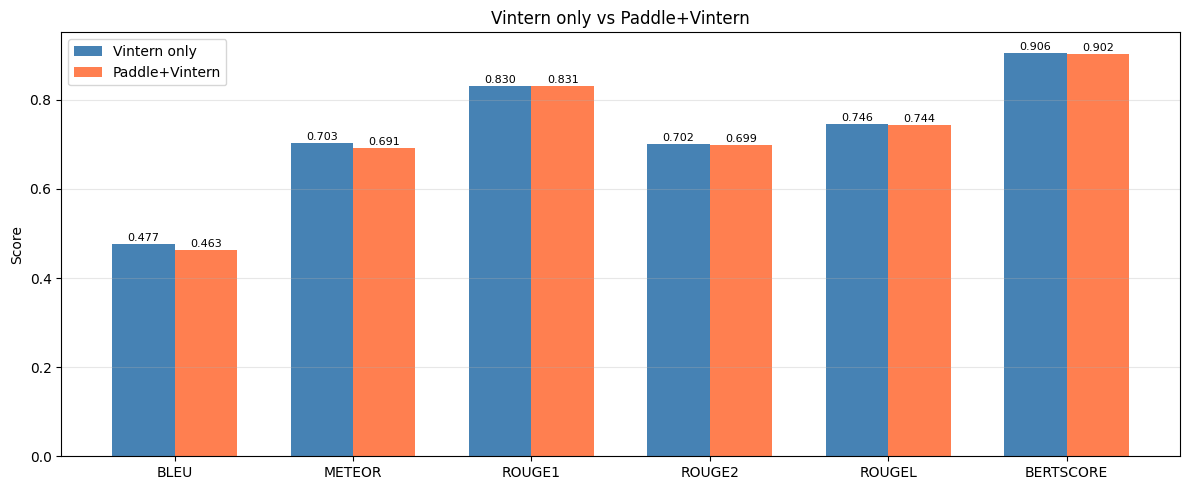

Saved: compare_chart.png


In [13]:
# Cell 13: Bảng so sánh tổng hợp
metrics = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']

def avg(results, metric):
    vals = [r[metric] for r in results]
    return sum(vals) / len(vals) if vals else 0.0

import matplotlib.pyplot as plt

compare = {
    'Metric'        : [m.upper() for m in metrics],
    'Vintern only'  : [round(avg(results_A, m), 4) for m in metrics],
    'Paddle+Vintern': [round(avg(results_B, m), 4) for m in metrics],
}
compare_df = pd.DataFrame(compare)
compare_df['Diff (+Paddle)'] = (compare_df['Paddle+Vintern'] - compare_df['Vintern only']).round(4)

print("\n=== Kết quả so sánh ===")
print(compare_df.to_string(index=False))

# Vẽ biểu đồ
x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar([i-width/2 for i in x], compare_df['Vintern only'],   width, label='Vintern only',   color='steelblue')
b2 = ax.bar([i+width/2 for i in x], compare_df['Paddle+Vintern'], width, label='Paddle+Vintern', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(compare_df['Metric'])
ax.set_ylabel('Score')
ax.set_title('Vintern only vs Paddle+Vintern')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/compare_chart.png', dpi=150)
plt.show()
print("Saved: compare_chart.png")

In [ ]:
# Cell 14: Lưu CSV chi tiết và zip
df_A = pd.DataFrame(results_A).add_suffix('_vintern')
df_B = pd.DataFrame(results_B).add_suffix('_paddle')

# Merge theo id
df_A = df_A.rename(columns={'id_vintern': 'id', 'question_vintern': 'question', 'ground_truth_vintern': 'ground_truth'})
df_B = df_B.rename(columns={'id_paddle': 'id'})

merged_df = df_A.merge(df_B[['id', 'response_paddle', 'bleu_paddle', 'meteor_paddle',
                               'rouge1_paddle', 'rouge2_paddle', 'rougeL_paddle', 'bertscore_paddle']], on='id')
merged_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"Saved: {OUTPUT_CSV}")

import zipfile
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(OUTPUT_CSV, "eval_results.csv")
    zf.write('/kaggle/working/compare_chart.png', "compare_chart.png")

print(f" Zipped: {OUTPUT_ZIP}")